# MZM MoE PINN Model

## Overview
This notebook implements a Physics-Informed Neural Network (PINN) architecture for modeling a Mach-Zehnder Modulator (MZM). The model is built using PyTorch and includes:

- Data preprocessing
- Custom activation functions
- Flexible neural network design
- Training loop with learning rate scheduling
- Performance visualization

The goal is to approximate nonlinear relationships between device parameters and output performance metrics.


In [1]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import re
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# random seed for selecting test set
random_state = 123

# Custum functions are defined here
class GaussianActivation(nn.Module):
    def forward(self, x):
        return torch.exp(-x**2)

def weights_init(layer_in):
  # Initialize the parameters with He initialization
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    # nn.init.xavier_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

def create_flexible_nn(input_dim, output_dim, hidden_dims, activation_fn=nn.ReLU(),positive_output=False):
    """
    Create a flexible neural network with variable number of hidden layers

    Args:
        input_dim (int): Number of input features
        output_dim (int): Number of output targets
        hidden_dims (list): List of integers specifying hidden layer dimensions
        activation_fn: Activation function to use between layers
    """
    layers = []

    # Input layer
    layers.append(nn.Linear(input_dim, hidden_dims[0]))
    layers.append(activation_fn)

    # Hidden layers
    for i in range(len(hidden_dims) - 1):
        layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
        layers.append(activation_fn)

    # Output layer
    layers.append(nn.Linear(hidden_dims[-1], output_dim))

    # If positivity is requested, append a Softplus
    if positive_output:
        layers.append(nn.Softplus())

    return nn.Sequential(*layers)

class ExpertNN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, activation_fn=nn.ReLU(),
             dropout_rate=0.0, use_bn=False):
        super().__init__()
        layers = []

        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation_fn)
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, n_experts=3,
             activation_fn=nn.ReLU(), gating_hidden=32,
             dropout_rate=0.0, use_bn=False):
        super().__init__()
        self.experts = nn.ModuleList([
            ExpertNN(input_dim, output_dim, hidden_dims,
                    activation_fn, dropout_rate, use_bn)
            for _ in range(n_experts)
        ])
        self.gating = nn.Sequential(
            nn.Linear(input_dim, gating_hidden),
            nn.ReLU(),
            nn.Linear(gating_hidden, n_experts),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        # Gating weights
        gate_weights = self.gating(x)  # [batch, n_experts]
        # Experts’ outputs
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=2)  # [batch, output_dim, n_experts]
        # Weighted sum
        out = torch.bmm(expert_outputs, gate_weights.unsqueeze(2)).squeeze(2)  # [batch, output_dim]
        return out

## Neural Network Architecture Design

In this section, we define:

- Input dimension (`D_i`)
- Output dimension (`D_o`)
- Hidden layer structure (`D_h`)
- Activation function

The architecture is intentionally flexible so it can be tuned for bias-variance tradeoff optimization.


In [3]:
###### Design the NN architecture

acivation_fun = nn.ReLU()
# acivation_fun = nn.Tanh()
# acivation_fun = GaussianActivation()

D_i = 8        # Input dimensions
D_o = 3        # Output dimensions
# Hidden layer dimensions
# D_h = [64, 128, 256, 128, 64]
# D_h = [200, 300, 350, 300, 200]
# D_h = [8,7,6,5,4]
# D_h = [8,6,6]
D_h = [64, 128, 64]

#positive_output = False # True if we want a constraint to ensure +ve "BW_3dB", "IL", "V_pi" DOESN'T WORK WITH NORMALIZATION
#model = create_flexible_nn(D_i, D_o, D_h, acivation_fun,positive_output)
n_experts = 60  # number of experts in MoE model
gating_hidden_layer_width = 8 #width of the gating hidden layer
dropout_rate = 0.0 # dropout rate (regularization parameter)
use_bn = True # Batch normalization flag

model_data = MixtureOfExperts(
    D_i, D_o, D_h,
    n_experts=n_experts,
    activation_fn=acivation_fun,
    gating_hidden=gating_hidden_layer_width,
    dropout_rate=dropout_rate,
    use_bn=use_bn
)

print(model_data)
print(f"\nNumber of parameters: {sum(p.numel() for p in model_data.parameters())}")

# Design the NN training module

# SGD parameters
batch_size = 128
learning_rate = 1e-3 #1e-3
weight_decay = 0.05 # Regularization parameter 0.05
momentum = 0.9 # used in momentum SGD optimizer
betas = (0.9, 0.999) # used in Adam optimizer beta1=0.9, beta2=0.999

# Schedular parameters
LR_scheduler_gamma = 0.5 # decrease learning by 0.5 every N steps
LR_scheduler_step = 100 # step size parameter N of the LR scheduler
n_epoch = 100 # loop over the dataset n_epoch, e.g., 200 times

# define MSE as loss function (regression problem)
loss_function = nn.MSELoss()

# construct SGD optimizer
# optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, weight_decay=weight_decay, momentum=momentum)
optimizer = torch.optim.AdamW(model_data.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=betas)

# learning rate schedular by half every 10 epochs
# scheduler = StepLR(optimizer, step_size=LR_scheduler_step, gamma=LR_scheduler_gamma)

MixtureOfExperts(
  (experts): ModuleList(
    (0-49): 50 x ExpertNN(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=8, bias=True)
        (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=8, out_features=6, bias=True)
        (4): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Linear(in_features=6, out_features=6, bias=True)
        (7): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): ReLU()
        (9): Linear(in_features=6, out_features=3, bias=True)
      )
    )
  )
  (gating): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=50, bias=True)
    (3): Softmax(dim=1)
  )
)

Number of parameters: 11972


In [4]:
# Mount Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Load and scale data
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]
print(df.head()) # for debugging only to check the data

      PN_offset  Bias_V    Core_width      P+_width      N+_width  \
0 -2.150000e-07   -10.0  4.500000e-07  2.062650e-07  1.083980e-07   
1 -2.150000e-07   -10.0  4.500000e-07  3.059360e-07  3.005950e-07   
2 -2.150000e-07   -10.0  5.081920e-07  2.085450e-07  1.936980e-07   
3 -2.150000e-07   -10.0  5.146500e-07  2.985000e-07  3.407150e-07   
4 -2.150000e-07   -10.0  5.180810e-07  1.589440e-07  2.348480e-07   

        P_width       N_width  Phase_length     BW_3dB       IL     V_pi  
0  1.000000e-06  7.551270e-07      0.002402  51.200000  2.58569  30.6728  
1  1.000000e-06  6.000000e-07      0.003196  36.179487  3.00849  39.7924  
2  8.262140e-07  7.634800e-07      0.002991  42.461539  2.82829  33.4881  
3  6.387450e-07  8.128130e-07      0.002953  38.692308  2.67160  40.2870  
4  6.000000e-07  6.000000e-07      0.001487  60.800000  1.39794  75.1647  


In [5]:
# Remove the rows where Vpi is above a threshold (data cleaning)
df_cleaned = df[df['V_pi'] < 500].copy()

# Split data into features/targets
feature_cols = df_cleaned.columns[:8]  # first 8 columns
target_cols = df_cleaned.columns[8:]   # last 3 columns

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values
# print(y[:3]) # for debugging only to check the data

# Train-test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state)

# Fit scalers on TRAINING data only
scaler_x = StandardScaler()

# Scale each target variable SEPARATELY
scaler_y1 = StandardScaler()  # For BW_3dB
scaler_y2 = StandardScaler()  # For IL
scaler_y3 = StandardScaler()  # For V_pi

# Scale features (x) - one scaler is fine
x_train_scaled = scaler_x.fit_transform(x_train_raw)

# Scale each target dimension INDEPENDENTLY
y_train_scaled_1 = scaler_y1.fit_transform(y_train_raw[:, 0:1])  # BW_3dB
y_train_scaled_2 = scaler_y2.fit_transform(y_train_raw[:, 1:2])  # IL
y_train_scaled_3 = scaler_y3.fit_transform(y_train_raw[:, 2:3])  # V_pi

# Combine targets back together
y_train_scaled = np.hstack([y_train_scaled_1, y_train_scaled_2, y_train_scaled_3])

# Transform TEST data using training parameters
x_test_scaled = scaler_x.transform(x_test_raw)

# Transform each test target separately
y_test_scaled_1 = scaler_y1.transform(y_test_raw[:, 0:1])  # BW_3dB
y_test_scaled_2 = scaler_y2.transform(y_test_raw[:, 1:2])  # IL
y_test_scaled_3 = scaler_y3.transform(y_test_raw[:, 2:3])  # V_pi
y_test_scaled = np.hstack([y_test_scaled_1, y_test_scaled_2, y_test_scaled_3])

# Convert to tensors
x_train = torch.from_numpy(x_train_scaled).float()
y_train = torch.from_numpy(y_train_scaled).float()
x_test = torch.from_numpy(x_test_scaled).float()
y_test = torch.from_numpy(y_test_scaled).float()

The outputs are:

- BW_3dB

- IL

- V_pi

These are macroscopic performance metrics, not modeling the field profile directly, so solving full Maxwell is overkill. The most reasonable PINN constraint here is Phase Accumulation Relation enforced by gradients.

## ✔ Constraint 1: Monotonic Bandwidth vs Length

Physically:

$$
BW \propto \frac{1}{L}
$$

So:

$$
\frac{\partial BW}{\partial L} \le 0
$$

This must be enforced via autograd, not sorting.

---

## ✔ Constraint 2: Insertion Loss increases with Length

$$
\frac{\partial IL}{\partial L} \ge 0
$$

Longer waveguide → more absorption.

---

## ✔ Constraint 3: Vπ scales inversely with L

$$
V_\pi \cdot L = constant
$$

Instead of using dataset mean, enforce:

$$
\frac{\partial (V_\pi L)}{\partial L} \approx 0
$$

---

## ✔ Constraint 4: Smoothness Constraint

Device metrics should be smooth functions of geometry.

So penalize second derivatives:

$$
\left|\frac{\partial^2 y}{\partial L^2}\right|
$$

In [6]:
# ==============================
# GPU Setup
# ==============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model and all data to GPU
model_data.to(device)
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test  = x_test.to(device)
y_test  = y_test.to(device)

# Precompute constant for Vpi*L on GPU
with torch.no_grad():
    VpiL_const = (y_train[:, 2] * x_train[:, 7]).mean()

# Store polynomial fit coefficients on GPU
L_train_np = x_train[:,7].cpu().numpy()  # polyfit uses numpy, move to CPU
BW_train_np = y_train[:,0].cpu().numpy()
coeffs = np.polyfit(L_train_np, BW_train_np, deg=2)  # [a2, a1, a0]
BW_coeffs = torch.tensor(coeffs, dtype=torch.float32, device=device)

# Training errors storage
errors_train = np.zeros((n_epoch))
errors_test  = np.zeros((n_epoch))

Using device: cuda


In [7]:
# -- Precompute constant for VpiL
with torch.no_grad():
    VpiL_const = (y_train[:, 2] * x_train[:, 7]).mean()

# Define weights for each physics term
lambda_vpiL    = 0.0
lambda_bw_mon  = 0.0
lambda_IL_mon  = 0.0
lambda_pos     = 0.0
lambda_bw_poly = 0.2

data_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    worker_init_fn=np.random.seed(1)
)

model_data.apply(weights_init)

MixtureOfExperts(
  (experts): ModuleList(
    (0-49): 50 x ExpertNN(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=8, bias=True)
        (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=8, out_features=6, bias=True)
        (4): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Linear(in_features=6, out_features=6, bias=True)
        (7): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): ReLU()
        (9): Linear(in_features=6, out_features=3, bias=True)
      )
    )
  )
  (gating): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=50, bias=True)
    (3): Softmax(dim=1)
  )
)

In [8]:
# ==============================
# Training Loop
# ==============================
for epoch in range(n_epoch):
    model_data.train()
    for x_batch, y_batch in data_loader:
        # Move batch to GPU
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model_data(x_batch)

        # Data loss
        data_loss = loss_function(pred, y_batch)

        # Physics-informed losses
        physics_loss_total = 0.0

        # 1) Vpi*L constant
        if lambda_vpiL != 0:
            Vpi_pred = pred[:,2]
            L_batch  = x_batch[:,7]
            residual_vpi = Vpi_pred * L_batch - VpiL_const
            physics_loss_vpiL = torch.mean(residual_vpi**2)
            physics_loss_total += lambda_vpiL * physics_loss_vpiL

        # 2) BW monotonic decreasing w.r.t L
        if lambda_bw_mon != 0:
            L_sorted, idx = torch.sort(x_batch[:,7])
            BW_sorted = pred[idx][:,0]
            violation_bw = torch.relu(BW_sorted[1:] - BW_sorted[:-1])
            physics_loss_bw = torch.mean(violation_bw**2)
            physics_loss_total += lambda_bw_mon * physics_loss_bw

        # 3) IL monotonic increasing w.r.t L
        if lambda_IL_mon != 0:
            IL_sorted = pred[idx][:,1]
            violation_il = torch.relu(IL_sorted[:-1] - IL_sorted[1:])
            physics_loss_il = torch.mean(violation_il**2)
            physics_loss_total += lambda_IL_mon * physics_loss_il

        # 4) Positivity penalty
        if lambda_pos != 0:
            neg_penalty = torch.relu(-pred)
            physics_loss_pos = torch.mean(neg_penalty**2)
            physics_loss_total += lambda_pos * physics_loss_pos

        # 5) BW polynomial fit consistency
        if lambda_bw_poly != 0:
            L_batch = x_batch[:,7]
            BW_pred = pred[:,0]
            BW_fit = BW_coeffs[0] * L_batch**2 + BW_coeffs[1] * L_batch + BW_coeffs[2]
            residual_bw_poly = BW_pred - BW_fit
            physics_loss_bw_poly = torch.mean(residual_bw_poly**2)
            physics_loss_total += lambda_bw_poly * physics_loss_bw_poly

        # Total loss
        loss = data_loss + physics_loss_total
        loss.backward()
        optimizer.step()

    # ==============================
    # Evaluation (no_grad, GPU)
    # ==============================
    model_data.eval()
        with torch.no_grad():
        pred_train = model_data(x_train)
        pred_test  = model_data(x_test)

        train_loss = loss_function(pred_train, y_train).item()
        test_loss  = loss_function(pred_test, y_test).item()

        errors_train[epoch] = train_loss
        errors_test[epoch]  = test_loss

        # Print every 10 epochs + first epoch
        if epoch % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch:5d}, train MSE {train_loss:.4f}, test MSE {test_loss:.4f}")

Epoch     0, train MSE 0.5561, test MSE 0.5682
Epoch    10, train MSE 0.0699, test MSE 0.0889
Epoch    20, train MSE 0.0549, test MSE 0.0779
Epoch    30, train MSE 0.0506, test MSE 0.0749
Epoch    40, train MSE 0.0478, test MSE 0.0732
Epoch    50, train MSE 0.0461, test MSE 0.0711
Epoch    60, train MSE 0.0444, test MSE 0.0705
Epoch    70, train MSE 0.0439, test MSE 0.0708
Epoch    80, train MSE 0.0425, test MSE 0.0699
Epoch    90, train MSE 0.0406, test MSE 0.0715


## Training Performance Visualization

This section plots the Mean Squared Error (MSE) for both training and testing sets across epochs.

Monitoring both curves allows us to detect:
- Overfitting (train ↓, test ↑)
- Underfitting (both high)
- Proper convergence (both ↓ and stable)


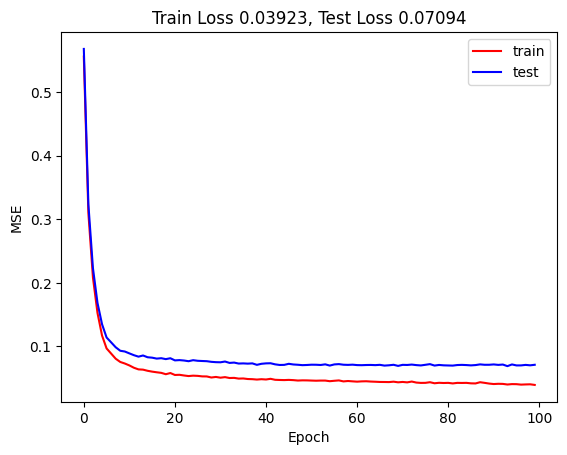

In [9]:
# Plot the results
fig, ax = plt.subplots()
ax.plot(errors_train,'r-',label='train')
ax.plot(errors_test,'b-',label='test')
#ax.set_ylim(0,100); ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Train Loss %3.5f, Test Loss %3.5f'%(errors_train[-1],errors_test[-1]))
ax.legend()
plt.show()

In [19]:
# Physics Informed Model
model_pinn = MixtureOfExperts(
    D_i, D_o, D_h,
    n_experts=n_experts,
    activation_fn=acivation_fun,
    gating_hidden=gating_hidden_layer_width,
    dropout_rate=dropout_rate,
    use_bn=use_bn
)
model_pinn.apply(weights_init)
model_pinn.to(device)

lambda_bw_mon = 0.1
lambda_IL_mon = 0.1
lambda_vpiL   = 0.05
lambda_smooth = 0.01

optimizer = torch.optim.AdamW(model_pinn.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=betas)

In [20]:
# ==============================
# Training Loop
# ==============================

for epoch in range(n_epoch):

    model_pinn.train()

    for x_batch, y_batch in data_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        x_batch.requires_grad_(True)

        optimizer.zero_grad()

        pred = model_pinn(x_batch)

        data_loss = loss_function(pred, y_batch)

        BW_pred  = pred[:, 0]
        IL_pred  = pred[:, 1]
        Vpi_pred = pred[:, 2]
        L_batch  = x_batch[:, 7]

        physics_loss_total = 0.0

        # =========================================
        # 1) dBW/dL <= 0
        # =========================================
        if lambda_bw_mon != 0:

            grads = torch.autograd.grad(
                BW_pred,
                x_batch,
                grad_outputs=torch.ones_like(BW_pred),
                create_graph=True
            )[0]

            dBW_dL = grads[:, 7]

            physics_bw = torch.mean(torch.relu(dBW_dL) ** 2)
            physics_loss_total += lambda_bw_mon * physics_bw


        # =========================================
        # 2) dIL/dL >= 0
        # =========================================
        if lambda_IL_mon != 0:

            grads = torch.autograd.grad(
                IL_pred,
                x_batch,
                grad_outputs=torch.ones_like(IL_pred),
                create_graph=True
            )[0]

            dIL_dL = grads[:, 7]

            physics_il = torch.mean(torch.relu(-dIL_dL) ** 2)
            physics_loss_total += lambda_IL_mon * physics_il


        # =========================================
        # 3) d(Vpi*L)/dL ≈ 0
        # =========================================
        if lambda_vpiL != 0:

            VpiL = Vpi_pred * L_batch

            grads = torch.autograd.grad(
                VpiL,
                x_batch,
                grad_outputs=torch.ones_like(VpiL),
                create_graph=True
            )[0]

            dVpiL_dL = grads[:, 7]

            physics_vpiL = torch.mean(dVpiL_dL ** 2)
            physics_loss_total += lambda_vpiL * physics_vpiL


        # =========================================
        # 4) Smoothness (second derivative of BW)
        # =========================================
        if lambda_smooth != 0:

            grads1 = torch.autograd.grad(
                BW_pred,
                x_batch,
                grad_outputs=torch.ones_like(BW_pred),
                create_graph=True
            )[0]

            dBW_dL = grads1[:, 7]

            grads2 = torch.autograd.grad(
                dBW_dL,
                x_batch,
                grad_outputs=torch.ones_like(dBW_dL),
                create_graph=True
            )[0]

            d2BW_dL2 = grads2[:, 7]

            physics_smooth = torch.mean(d2BW_dL2 ** 2)
            physics_loss_total += lambda_smooth * physics_smooth


        loss = data_loss + physics_loss_total

        loss.backward()
        optimizer.step()


    # =========================
    # Evaluation
    # =========================
    model_pinn.eval()
    with torch.no_grad():

        pred_train = model_pinn(x_train)
        pred_test  = model_pinn(x_test)

        train_loss = loss_function(pred_train, y_train).item()
        test_loss  = loss_function(pred_test, y_test).item()

        errors_train[epoch] = train_loss
        errors_test[epoch]  = test_loss

        if epoch % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch:5d} | Train {train_loss:.6f} | Test {test_loss:.6f}")

Epoch     0 | Train 0.577587 | Test 0.602078
Epoch    10 | Train 0.078204 | Test 0.101025
Epoch    20 | Train 0.053335 | Test 0.077052
Epoch    30 | Train 0.046076 | Test 0.070806
Epoch    40 | Train 0.043260 | Test 0.068207
Epoch    50 | Train 0.040504 | Test 0.065854
Epoch    60 | Train 0.038483 | Test 0.064187
Epoch    70 | Train 0.037348 | Test 0.064485
Epoch    80 | Train 0.037371 | Test 0.066420
Epoch    90 | Train 0.034940 | Test 0.064381


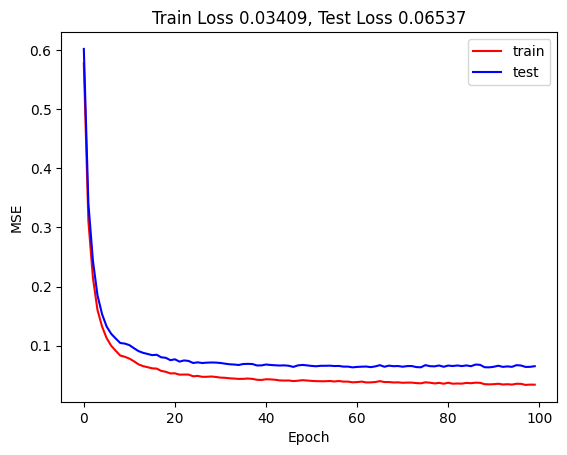

In [21]:
# Plot the results
fig, ax = plt.subplots()
ax.plot(errors_train,'r-',label='train')
ax.plot(errors_test,'b-',label='test')
#ax.set_ylim(0,100); ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Train Loss %3.5f, Test Loss %3.5f'%(errors_train[-1],errors_test[-1]))
ax.legend()
plt.show()